# O risco aparece na combinação de sinais?

Esta análise investiga `output/vrum_timeline_completa.csv` no contexto do VRUM. A pergunta central é se frequência de passagens, intervalo desde a passagem anterior e alternância PF/PJ formam um padrão associado ao evento de risco em 90 dias.

A unidade de comparação será a proposta de financiamento. Linhas `EVENTO_RISCO` representam o desfecho futuro e não entram como observações preditoras.

## O arquivo foi lido com separador, tipos e datas corretos?

Primeiro confirmamos estrutura, tamanho e amostra antes de interpretar qualquer indicador.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import polars as pl

COR_PRIMARIA = "#0072B2"
COR_SECUNDARIA = "#94A3B8"
COR_DESTAQUE = "#E69F00"
PALETA = [COR_PRIMARIA, COR_DESTAQUE, "#009E73", "#CC79A7"]
plt.rcParams.update({"figure.figsize": (10, 6), "figure.dpi": 110, "font.size": 11, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.25})

nome_arquivo = "vrum_timeline_completa.csv"
candidatos = [Path.cwd().parent / "output" / nome_arquivo, Path.cwd() / "output" / nome_arquivo]
caminho = next((p for p in candidatos if p.exists()), None)
if caminho is None:
    raise FileNotFoundError(f"Arquivo não encontrado: {nome_arquivo}")

timeline = pl.read_csv(caminho, separator=";", null_values=[""], try_parse_dates=False, infer_schema_length=10_000)
timeline = timeline.with_columns([
    pl.col("data_hora_proposta").str.strptime(pl.Datetime, "%Y-%m-%d %H:%M:%S", strict=False),
    pl.col("dt_evento").str.strptime(pl.Datetime, "%Y-%m-%d %H:%M:%S", strict=False),
    pl.col("dt_evento_anterior").str.strptime(pl.Datetime, "%Y-%m-%d %H:%M:%S", strict=False),
])
print(f"Arquivo: {caminho}")

Arquivo: /var/home/andpax/Workspace/projetos/vscode-workspace/vrum/output/vrum_timeline_completa.csv


In [2]:
print("Dimensão:", timeline.shape)
print("Esquema:")
print(timeline.schema)
timeline.head(5)

Dimensão: (2160408, 25)
Esquema:
Schema({'id_proposta': String, 'data_hora_proposta': Datetime(time_unit='us', time_zone=None), 'chassi_id_sintetico': String, 'if_id_sintetico': String, 'cpf_cnpj_proponente_sintetico': String, 'tipo_proponente': String, 'valor_financiado': Float64, 'valor_entrada': Float64, 'prazo_meses': Float64, 'canal': String, 'uf_proposta': String, 'dt_evento': Datetime(time_unit='us', time_zone=None), 'tipo_evento': String, 'subtipo_evento': String, 'origem_registro': String, 'prioridade_tipo': Int64, 'evento_risco_chassi_90d': Float64, 'dt_evento_anterior': Datetime(time_unit='us', time_zone=None), 'dias_desde_ultima_passagem': Float64, 'proponente_anterior': String, 'flag_alternancia_pf_pj': Int64, 'qtd_passagens_7d': Int64, 'qtd_passagens_15d': Int64, 'qtd_passagens_30d': Int64, 'qtd_passagens_90d': Int64})


id_proposta,data_hora_proposta,chassi_id_sintetico,if_id_sintetico,cpf_cnpj_proponente_sintetico,tipo_proponente,valor_financiado,valor_entrada,prazo_meses,canal,uf_proposta,dt_evento,tipo_evento,subtipo_evento,origem_registro,prioridade_tipo,evento_risco_chassi_90d,dt_evento_anterior,dias_desde_ultima_passagem,proponente_anterior,flag_alternancia_pf_pj,qtd_passagens_7d,qtd_passagens_15d,qtd_passagens_30d,qtd_passagens_90d
str,datetime[μs],str,str,str,str,f64,f64,f64,str,str,datetime[μs],str,str,str,i64,f64,datetime[μs],f64,str,i64,i64,i64,i64,i64
"""PROP_CHASSI_0001629494""",2026-03-28 14:23:58,"""CHASSI_SYN_000000001""","""IF_SYN_19""","""DOC_PROP_SYN_000161993""","""PJ""",111694.29,20857.49,24.0,"""CONCESSIONARIA""","""MG""",2026-03-28 14:23:58,"""PROPOSTA_FINANCIAMENTO""",null,"""PROPOSTA_FINANCIAMENTO""",1,null,null,null,null,0,0,0,0,0
"""PROP_CHASSI_0001922838""",2026-03-03 14:24:56,"""CHASSI_SYN_000000002""","""IF_SYN_15""","""DOC_PROP_SYN_000026373""","""PF""",40325.62,14324.16,24.0,"""DIGITAL""","""GO""",2026-03-03 14:24:56,"""PROPOSTA_FINANCIAMENTO""",null,"""PROPOSTA_FINANCIAMENTO""",1,null,null,null,null,0,0,0,0,0
"""PROP_CHASSI_0002119571""",2026-03-07 10:24:04,"""CHASSI_SYN_000000002""","""IF_SYN_02""","""DOC_PROP_SYN_000249555""","""PJ""",168768.32,53555.71,60.0,"""CONCESSIONARIA""","""RJ""",2026-03-07 10:24:04,"""PROPOSTA_FINANCIAMENTO""",null,"""PROPOSTA_FINANCIAMENTO""",1,null,2026-03-03 14:24:56,3.0,"""PF""",1,1,1,1,1
"""PROP_CHASSI_0001843416""",2026-03-24 04:37:35,"""CHASSI_SYN_000000002""","""IF_SYN_16""","""DOC_PROP_SYN_000388553""","""PJ""",57018.44,9478.08,24.0,"""DIGITAL""","""MG""",2026-03-24 04:37:35,"""PROPOSTA_FINANCIAMENTO""",null,"""PROPOSTA_FINANCIAMENTO""",1,null,2026-03-07 10:24:04,16.0,"""PJ""",0,0,0,1,1
"""PROP_CHASSI_0001474584""",2026-02-04 05:36:07,"""CHASSI_SYN_000000003""","""IF_SYN_17""","""DOC_PROP_SYN_000067251""","""PF""",116952.91,30867.09,24.0,"""LOJA_MULTIMARCA""","""PE""",2026-02-04 05:36:07,"""PROPOSTA_FINANCIAMENTO""",null,"""PROPOSTA_FINANCIAMENTO""",1,null,null,null,null,0,0,0,0,0


**Resultado:** separador `;`, rótulos e tipos numéricos foram reconhecidos. O arquivo é uma timeline longa: mistura propostas com eventos de risco derivados. Datas de proposta e de evento precisam permanecer separadas na leitura temporal.

## Qual é a unidade correta de análise?

Contamos linhas por origem e verificamos IDs repetidos. Isso evita tratar o evento futuro como uma segunda proposta.

In [3]:
por_origem = timeline.group_by("origem_registro").agg(pl.len().alias("n")).sort("n", descending=True)
duplicados = timeline.group_by("id_proposta").agg(pl.len().alias("n_linhas")).filter(pl.col("n_linhas") > 1)
print(por_origem)
print(duplicados.select([pl.len().alias("ids_repetidos"), pl.col("n_linhas").min().alias("min_linhas"), pl.col("n_linhas").max().alias("max_linhas")]))

shape: (2, 2)
┌────────────────────────┬─────────┐
│ origem_registro        ┆ n       │
│ ---                    ┆ ---     │
│ str                    ┆ u32     │
╞════════════════════════╪═════════╡
│ PROPOSTA_FINANCIAMENTO ┆ 2129214 │
│ EVENTO_RISCO           ┆ 31194   │
└────────────────────────┴─────────┘
shape: (1, 3)
┌───────────────┬────────────┬────────────┐
│ ids_repetidos ┆ min_linhas ┆ max_linhas │
│ ---           ┆ ---        ┆ ---        │
│ u32           ┆ u32        ┆ u32        │
╞═══════════════╪════════════╪════════════╡
│ 31194         ┆ 2          ┆ 2          │
└───────────────┴────────────┴────────────┘


**Resultado:** cada ID repetido corresponde à proposta e ao evento futuro associado. A análise preditiva deve usar apenas as linhas `PROPOSTA_FINANCIAMENTO`; os eventos servem para construir o alvo.

## O evento de risco pode ser ligado à proposta sem ambiguidade?

Reconstruímos o alvo pela presença de uma linha `EVENTO_RISCO` com o mesmo `id_proposta`. Depois, juntamos esse alvo às propostas.

In [4]:
propostas = timeline.filter(pl.col("origem_registro") == "PROPOSTA_FINANCIAMENTO")
eventos_risco = (timeline.filter(pl.col("origem_registro") == "EVENTO_RISCO").select(["id_proposta", "subtipo_evento", "dt_evento"]).unique("id_proposta").rename({"subtipo_evento": "tipo_risco", "dt_evento": "dt_risco"}).with_columns(pl.lit(1).cast(pl.Int8).alias("target_risco_90d")))
base = propostas.join(eventos_risco, on="id_proposta", how="left").with_columns(pl.col("target_risco_90d").fill_null(0).cast(pl.Int8))
integridade = eventos_risco.select(pl.len().alias("eventos")).with_columns(pl.lit(eventos_risco.join(propostas.select("id_proposta"), on="id_proposta", how="anti").height).alias("eventos_sem_proposta"))
resumo_alvo = base.select([pl.len().alias("propostas"), pl.col("id_proposta").n_unique().alias("ids_unicos"), pl.col("target_risco_90d").sum().alias("positivos"), pl.col("target_risco_90d").mean().alias("taxa")])
print(integridade)
resumo_alvo

shape: (1, 2)
┌─────────┬──────────────────────┐
│ eventos ┆ eventos_sem_proposta │
│ ---     ┆ ---                  │
│ u32     ┆ i32                  │
╞═════════╪══════════════════════╡
│ 31194   ┆ 0                    │
└─────────┴──────────────────────┘


propostas,ids_unicos,positivos,taxa
u32,u32,i64,f64
2129214,2129214,31194,0.01465


**Resultado:** o alvo é reconstruível por chave e não há evento órfão. A taxa de risco é baixa, portanto toda comparação precisa exibir `n` e taxa; contagens brutas podem confundir tamanho da população com risco.

## A janela temporal do alvo é compatível com o desenho do projeto?

Comparamos a cobertura temporal das propostas e dos eventos.

In [5]:
timeline.select([
    pl.col("data_hora_proposta").min().alias("inicio_propostas"),
    pl.col("data_hora_proposta").max().alias("fim_propostas"),
    pl.col("dt_evento").min().alias("inicio_timeline"),
    pl.col("dt_evento").max().alias("fim_timeline"),
]).join(eventos_risco.group_by("tipo_risco").agg(pl.len().alias("n")).sort("n", descending=True), how="cross")

inicio_propostas,fim_propostas,inicio_timeline,fim_timeline,tipo_risco,n
datetime[μs],datetime[μs],datetime[μs],datetime[μs],str,u32
2026-01-01 00:00:06,2026-03-31 23:59:54,2026-01-01 00:00:06,2026-06-29 20:01:38,"""FRAUDE_CONFIRMADA""",10408
2026-01-01 00:00:06,2026-03-31 23:59:54,2026-01-01 00:00:06,2026-06-29 20:01:38,"""BUSCA_APREENSAO_INFRUTIFERA""",10403
2026-01-01 00:00:06,2026-03-31 23:59:54,2026-01-01 00:00:06,2026-06-29 20:01:38,"""NEVER_PAY""",10383


**Resultado:** propostas cobrem o primeiro trimestre; eventos avançam até aproximadamente 90 dias depois. O alvo é um desfecho futuro. Features calculadas com histórico anterior podem ser avaliadas, mas linhas e atributos do próprio evento de risco não podem entrar como preditores.

## Os campos ausentes representam problema de qualidade ou posição na timeline?

Medimos nulos apenas na base de propostas, distinguindo primeira passagem de dado ausente inesperado.

In [6]:
nulos = propostas.null_count().transpose(include_header=True, header_name="coluna", column_names=["nulos"]).filter(pl.col("nulos") > 0).sort("nulos", descending=True)
nulos.with_columns((pl.col("nulos") / propostas.height).alias("proporcao"))

coluna,nulos,proporcao
str,u32,f64
"""subtipo_evento""",2129214,1.0
"""evento_risco_chassi_90d""",2129214,1.0
"""proponente_anterior""",591944,0.278011
"""dt_evento_anterior""",582910,0.273768
"""dias_desde_ultima_passagem""",582910,0.273768


**Resultado:** nulos em `dt_evento_anterior` e `dias_desde_ultima_passagem` são esperados na primeira passagem de cada chassi; `proponente_anterior` também pode ficar ausente quando registro anterior é evento de risco. O alvo e `subtipo_evento` ficam nulos nas propostas por construção, pois foram reconstruídos a partir das linhas de evento. Nulos históricos não devem ser preenchidos como zero sem preservar essa distinção.

## O risco muda quando observamos frequência, permanência e alternância?

Começamos pela comparação dos principais indicadores entre propostas com e sem evento. `dias_desde_ultima_passagem` é intervalo entre registros, não uma medida direta de posse.

In [7]:
base.group_by("target_risco_90d").agg([
    pl.len().alias("n"),
    pl.col("qtd_passagens_7d").mean().alias("media_passagens_7d"),
    pl.col("qtd_passagens_30d").mean().alias("media_passagens_30d"),
    pl.col("qtd_passagens_90d").mean().alias("media_passagens_90d"),
    pl.col("dias_desde_ultima_passagem").median().alias("mediana_intervalo_dias"),
    pl.col("flag_alternancia_pf_pj").mean().alias("taxa_alternancia"),
]).sort("target_risco_90d")

target_risco_90d,n,media_passagens_7d,media_passagens_30d,media_passagens_90d,mediana_intervalo_dias,taxa_alternancia
i8,u32,f64,f64,f64,f64,f64
0,2098020,0.236452,0.608779,0.726216,12.0,0.27105
1,31194,0.23761,0.608771,0.727319,12.0,0.270789


**Resultado:** médias e medianas são praticamente iguais entre os dois grupos. Nenhum desses indicadores, sozinho, mostra separação útil nesta base.

## Quais categorias exibem risco acima ou abaixo da taxa-base?

Calculamos taxa, positivos e `n` para categorias e indicadores binários. A leitura correta é risco dentro do grupo, não participação do grupo no total.

In [8]:
def taxa_por_grupo(coluna, minimo=1_000):
    return (base.group_by(coluna).agg([pl.len().alias("n"), pl.col("target_risco_90d").sum().alias("positivos"), pl.col("target_risco_90d").mean().alias("taxa_risco")]).filter(pl.col("n") >= minimo).with_columns(pl.lit(coluna).alias("variavel"), pl.col(coluna).cast(pl.String).alias("valor")).select(["variavel", "valor", "n", "positivos", "taxa_risco"]).sort("taxa_risco", descending=True))
univariada = pl.concat([taxa_por_grupo(c) for c in ["tipo_proponente", "canal", "qtd_passagens_7d", "qtd_passagens_15d", "qtd_passagens_30d", "qtd_passagens_90d", "flag_alternancia_pf_pj"]])
univariada

variavel,valor,n,positivos,taxa_risco
str,str,u32,i64,f64
"""tipo_proponente""","""PJ""",533017,7863,0.014752
"""tipo_proponente""","""PF""",1596197,23331,0.014617
"""canal""","""DIGITAL""",710395,10475,0.014745
"""canal""","""CONCESSIONARIA""",709327,10391,0.014649
"""canal""","""LOJA_MULTIMARCA""",709492,10328,0.014557
…,…,…,…,…
"""qtd_passagens_30d""","""1""",1296220,18990,0.01465
"""qtd_passagens_90d""","""1""",1546304,22688,0.014672
"""qtd_passagens_90d""","""0""",582910,8506,0.014592


**Resultado:** as taxas dos grupos permanecem próximas da taxa-base, sem ranking estável que indique um `silver bullet`. Isso sustenta cautela contra decisões baseadas em uma única variável; ainda não prova que a combinação tenha sinal.

## A combinação de sinais cria gradiente de risco?

Criamos três indicadores transparentes: passagem anterior em até 30 dias, intervalo de até 5 dias e alternância PF/PJ. Somamos sinais para testar se mais sinais implicam maior taxa.

In [9]:
base = base.with_columns([
    (pl.col("qtd_passagens_30d") >= 1).cast(pl.Int8).alias("sinal_frequencia_30d"),
    (pl.col("dias_desde_ultima_passagem").is_not_null() & (pl.col("dias_desde_ultima_passagem") <= 5)).cast(pl.Int8).alias("sinal_intervalo_curto"),
    (pl.col("flag_alternancia_pf_pj") == 1).cast(pl.Int8).alias("sinal_alternancia_pf_pj"),
])
base = base.with_columns(pl.sum_horizontal(["sinal_frequencia_30d", "sinal_intervalo_curto", "sinal_alternancia_pf_pj"]).alias("qtd_sinais_multifatoriais"))
base.select(["id_proposta", "sinal_frequencia_30d", "sinal_intervalo_curto", "sinal_alternancia_pf_pj", "qtd_sinais_multifatoriais"]).head(5)

id_proposta,sinal_frequencia_30d,sinal_intervalo_curto,sinal_alternancia_pf_pj,qtd_sinais_multifatoriais
str,i8,i8,i8,i8
"""PROP_CHASSI_0001629494""",0,0,0,0
"""PROP_CHASSI_0001922838""",0,0,0,0
"""PROP_CHASSI_0002119571""",1,1,1,3
"""PROP_CHASSI_0001843416""",1,0,0,1
"""PROP_CHASSI_0001474584""",0,0,0,0


A transformação preserva indicadores binários auditáveis. O próximo quadro testa o desfecho por quantidade de sinais, sempre com tamanho de grupo e taxa.

In [10]:
taxa_base = base.select(pl.col("target_risco_90d").mean()).item()
combinado = (base.group_by("qtd_sinais_multifatoriais").agg([pl.len().alias("n"), pl.col("target_risco_90d").sum().alias("positivos"), pl.col("target_risco_90d").mean().alias("taxa_risco")]).with_columns((pl.col("taxa_risco") / taxa_base).alias("lift_vs_base")).sort("qtd_sinais_multifatoriais"))
combinado

qtd_sinais_multifatoriais,n,positivos,taxa_risco,lift_vs_base
i8,u32,i64,f64,f64
0,739461,10782,0.014581,0.99525
1,628646,9289,0.014776,1.008582
2,596304,8706,0.0146,0.99655
3,164803,2417,0.014666,1.001059


**Resultado:** a taxa não cresce de forma monotônica com a quantidade de sinais; os `lift`s ficam próximos de 1. Nesta versão do arquivo, nem a combinação proposta revela associação mensurável. Isso é um achado válido, mas impede afirmar que o dataset já demonstre a tese multifatorial.

## O padrão combinado fica visível no gráfico?

A visualização destaca a taxa-base e as taxas por quantidade de sinais, sem usar escala que transforme diferença mínima em evidência forte.

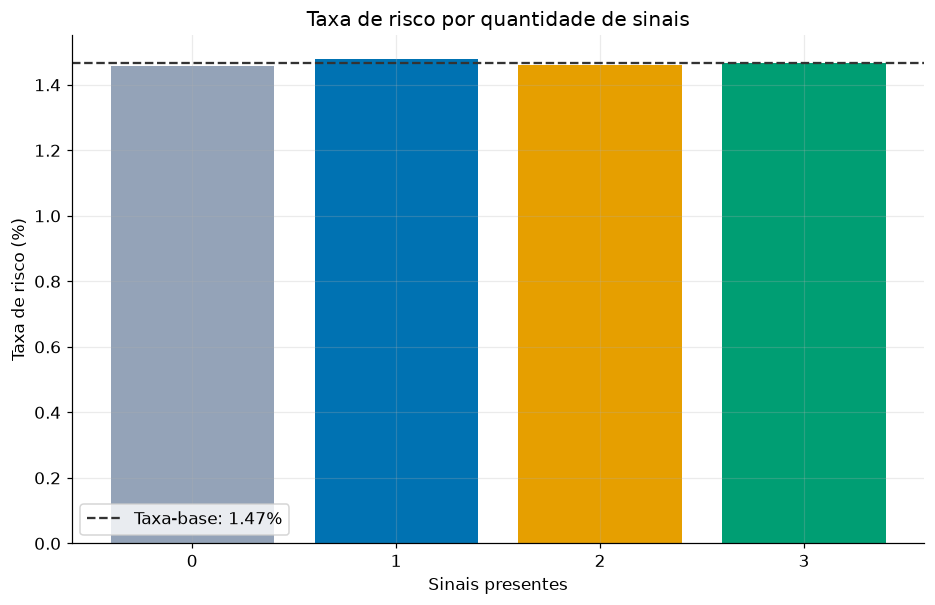

In [11]:
x = combinado["qtd_sinais_multifatoriais"].to_list()
y = [v * 100 for v in combinado["taxa_risco"].to_list()]
fig, ax = plt.subplots()
ax.bar([str(v) for v in x], y, color=[COR_SECUNDARIA, COR_PRIMARIA, COR_DESTAQUE, "#009E73"][:len(x)])
ax.axhline(taxa_base * 100, color="#333333", linestyle="--", label=f"Taxa-base: {taxa_base:.2%}")
ax.set(title="Taxa de risco por quantidade de sinais", xlabel="Sinais presentes", ylabel="Taxa de risco (%)")
ax.legend()
plt.show()

## Conclusões e próximos passos

- A tabela é uma timeline longa com propostas e eventos futuros; propostas são a unidade correta para EDA e modelagem.
- O alvo reconstruído tem baixa prevalência. Comparações devem exibir `n`, positivos, taxa e, na modelagem, métricas adequadas para desbalanceamento.
- Nenhum indicador isolado analisado separa os grupos de forma clara.
- O escore simples com frequência, intervalo curto e alternância também não apresenta gradiente neste arquivo.
- A hipótese multifatorial continua plausível como hipótese de negócio, mas estes dados não fornecem evidência suficiente para confirmá-la. Antes de XGBoost ou SHAP, revisar geração/semântica do target e verificar se há rótulos e features alinhados na mesma unidade temporal.
- Qualquer modelagem deve usar split temporal e excluir atributos derivados do próprio `EVENTO_RISCO`, evitando leakage.